# Train a model with the MLX framework using low hardware requirements

This notebook uses the [MLX machine learning framework](https://github.com/ml-explore/mlx) and uses less than 3GB of training data. Users will need  to run 'pip install mlx' as this is not a part of the default requirements file, as it is not available on all platforms.

Overview:
- Downloading training data (takes a few minutes)
- Training a neural network to predict global weather conditions (takes around 20-30 minutes per epoch)
- Inferencing the network on unseen data (takes only a moment)
- This tutorial demonstrates how to work with PyEarthTools using the MLX framework, which is designed for Apple Silicon.

## Summary

### Choice of Data
This tutorial allows the user to download a 2.8GB file (or 6.4GB if you choose to use additional variables). The data contains around 60 years of global Earth system analysis data. The term "analysis" means the science community's best estimate of historical weather conditions based on available observations. The analysis data set used here was originally produced by the [European Centre for Medium Range Weather Forecasting (ECMWF)](https://www.ecmwf.int/en/forecasts/dataset/ecmwf-reanalysis-v5). This is a standard data set used in the field, however most research is done on a higher-resolution version of the data. That said, valuable research is also done using the lower resolution data. The spatial (latitude and longitude) resolution of this data is 64 pixels by 32 pixels, but the time series is very long. Only a few of the most interesting variables are downloaded in this notebook, to reduce how much data must be downloaded and stored.

The data is made available by the ECMWF under license, and the conditions are described here: https://www.ecmwf.int/en/forecasts/accessing-forecasts/licences-available . Please review this before making use of the data for anything. In this tutorial, the data is downloaded using instructions from the WeatherBench 2 data guide. Please see https://weatherbench2.readthedocs.io/en/latest/data-guide.html for more information on the data, open access, and accessing other resolutions of the data.

### Note on the MLX Framework

As at 2025, PyTorch appears to have the most uptake among the weather and climate machine learning community, with TensorFlow and JAX also in use. These frameworks provide optimised implementations for NVidia GPUs and also function on CPUs, and on Apple devices through the 'MPS' back-end. 

The MLX framework is an alternative to PyTorch and TensorFlow, and is natively optimised for Apple Silicon (M-series) devices and chips. Providing an example implemented in this specific framework demonstrates that PyEarthTools is capable of supporting multiple machine learning frameworks. The MLX framework version used in this example was 0.26.1 and MLX was originally developed by Hannun, A., Digani, J., Katharopoulos, A., & Collobert, R. (2023), https://github.com/ml-explore .



In [1]:
import os

# IMPORTANT! Set this to where you want to store your copy of the data!
# os.environ['PETPROJECT'] = os.path.expanduser("~")  # to use your home directory
# os.environ['PETPROJECT'] = os.path.abspath('./')    # to use the current working directory
# os.environ['PETPROJECT'] = os.environ['PBS_JOBFS']  # to use a job-specific temporary directory
# os.environ['PETPROJECT'] = os.path.abspath('/tmp')  # to use the /tmp directory

# Most users should change this to the current directory.
os.environ['PETPROJECT'] = os.path.expanduser("~") + '/dev/proj/petcache'
workdir = os.environ['PETPROJECT']
# print(workdir)

import pathlib
import xarray as xr
from pathlib import Path
import time

import matplotlib.pyplot as plt

import pyearthtools.data.archive
import pyearthtools.tutorial
import pyearthtools.training
import pyearthtools.pipeline

import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim

In [2]:
file_location = workdir + '/mini.nc'

if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[['10m_u_component_of_wind', 
                          '10m_v_component_of_wind', 
                          '2m_temperature', 
                          'mean_sea_level_pressure',
                          'geopotential',  # Uncomment this to fetch additional data
                          'toa_incident_solar_radiation_6hr', # Uncomment this to fetch additional data
                          'temperature' # Uncomment this to fetch additional data
                         ]]

    bilevel = subset.sel({'level': [50, 500]}) # Uncomment if fetching addtional data    
    bilevel.to_netcdf(file_location)

    # subset.to_netcdf(file_location)  # Comment this out if using the bilevel data instead
    print("Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print("File already downloaded, skipping ...")

File already downloaded, skipping ...


In [3]:
accessor = pyearthtools.tutorial.ERA5DataClass.ERA5LowResDemoIndex([
                 '10m_u_component_of_wind', 
                 '10m_v_component_of_wind', 
                 'mean_sea_level_pressure',
                 '2m_temperature'    
],
filename_override=file_location)

In [4]:
# Print one sample data point from the accessor
sample = accessor['2010-01-01T00']
sample#['2m_temperature'].plot(x='longitude', y='latitude')

<xarray.Dataset> Size: 34kB
Dimensions:                  (time: 1, longitude: 64, latitude: 32)
Coordinates:
  * latitude                 (latitude) float64 256B -87.19 -81.56 ... 87.19
  * longitude                (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * time                     (time) datetime64[ns] 8B 2010-01-01
Data variables:
    2m_temperature           (time, longitude, latitude) float32 8kB 247.5 .....
    mean_sea_level_pressure  (time, longitude, latitude) float32 8kB 1.006e+0...
    10m_u_component_of_wind  (time, longitude, latitude) float32 8kB -4.426 ....
    10m_v_component_of_wind  (time, longitude, latitude) float32 8kB -5.147 ....

In [5]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),     
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1, 6)) # Input = 1 sample from time T=0 hours. Output = T+6,+12,+18,+24
    ),     
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=workdir),  # Incremental normalisation calculator    
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t h w c'), # channel batch height width -> batch height width channel
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours')
)
# data_pipeline

# Defining the Neural Network

In this notebook, we are not using PyEarthTools classes for creating a registered model or training wrapper. That would be worthwhile if the goal was to made the model itself available to a wider range of people, or encode design choices in a reference implementation that could be re-used. In this case, the goal is to show the process of neural network development directly. However, as the network is not a PyEarthTools registered model, a little bit more needs to be done after prediction to return the predictions into denormalised space as xarray objects - functionality that comes 'for free' with a registered model.

In [6]:
class CustomGriddedRegression(nn.Module):
    """
    Create a gridded resnet for roughly normalised regression problems
    """

    def __init__(self, num_channels, width, height):
        super().__init__()

        self.nc = num_channels
        self.w = width
        self.h = height
        
        self.layer1 = nn.Linear(self.nc, self.nc)
        self.layer2 = nn.Sigmoid()
        self.layer3 = nn.ReLU()
        self.layer4 = nn.Sigmoid()
        self.layer5 = nn.Linear(self.nc, self.nc)

    def __call__(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        return x

In [7]:
# Here we match the size of the era5 low-resolution data. It would be interesting to experiment with larger models.
model = CustomGriddedRegression(num_channels=4, width=64, height=32)

optimizer = optim.Adam(learning_rate=0.01)

def calculate_loss(model, x, y):

    x = mx.array(x)
    y = mx.array(y)
    yhat = model(x)
    loss = nn.losses.l1_loss(yhat, y)
    return loss
    
def train_epoch(max_steps):
    '''
    This is be called once per epoch, and it not parameterised
    '''

    i = 0
    printper = 1000
    lossper = 0
    tic = time.perf_counter()

    # Batch size of 1 here
    for inp, tgt in data_pipeline:
        train_step_fn = nn.value_and_grad(model, calculate_loss)
        loss, grads = train_step_fn(model, inp, tgt)
        lossper += loss
        optimizer.update(model, grads)
        mx.eval(model.parameters())

        i+= 1
        if i % printper == 0:
            toc = time.perf_counter()
            average_loss = lossper / 1000
            duration = toc - tic
            print(f'Step {i}')
            print(f'Average loss over 1000 steps: {average_loss}')
            print(f'Duration for 1000 steps: {duration}')
            tic = toc
            lossper = 0

        if max_steps > 0 and i > max_steps:
            return


def do_train(epochs=1, max_steps=0):

    count_epoch = 0
    for i in range(epochs):
        print(f'Commencing epoch {i}')
        train_epoch(max_steps)
        # tr_loss, tr_acc, throughput = train_epoch(max_steps)
        # print(" | ".join([epoch, tr_loss, tr_acc, throughput]))
    


In [ ]:
# There are around 52k samples to train from
# 1000 steps was taking about 30 seconds
# So a full epoch with this model would be around 26 minutes per epoch
# Reasonable skill on this benchmark model is reach after around 6000 steps
do_train(max_steps=10000)

In [18]:
model.save_weights(workdir+'/mlx_reasonable_0.safetensors')

In [13]:
inp, target = data_pipeline['2019-01-01']
yhat = model(mx.array(inp))

In [15]:
da_pred = xr.DataArray(yhat)
da_target = xr.DataArray(target)

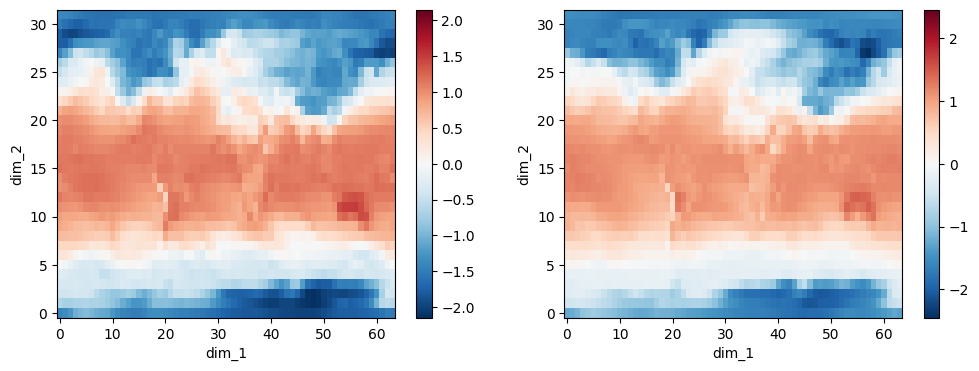

In [37]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))
da_pred[0, :, :, 2].plot(x='dim_1', y='dim_2', ax=axs[0],)
da_target[0, :, :, 2].plot(x='dim_1', y='dim_2', ax=axs[1])